<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📚 Import Required Libraries
</h2>

In [1]:
import pandas as pd
import numpy as np

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📂 Load the Datasets
</h2>

<p style="font-size:16px; line-height:1.8;">
Here we load the same two datasets used in the EDA — restaurant reviews and restaurant metadata.
</p>

In [2]:
reviews_df = pd.read_csv("Zomato Restaurant reviews.csv")
metadata_df = pd.read_csv("Zomato Restaurant names and Metadata.csv")

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🧹 Reviews Dataset Cleaning
</h2>

<p style="font-size:16px; line-height:1.8;">
We re-apply the same cleaning steps done during EDA — removing duplicates, dropping missing values, and converting the Rating column to numeric type so the data is ready for ML processing.
</p>

In [3]:
reviews_df.drop_duplicates(inplace=True)
reviews_df.dropna(inplace=True)
reviews_df = reviews_df[reviews_df["Rating"] != "Like"]
reviews_df["Rating"] = reviews_df["Rating"].astype(float)

### Observation
- Duplicate records and missing values have been successfully removed from the reviews dataset.
- The non-numeric value "Like" has been removed from the Rating column.
- The Rating column is now of float type, ready for ML processing.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🧹 Metadata Dataset Cleaning
</h2>

<p style="font-size:16px; line-height:1.8;">
Missing values in the Collections column are filled with "Not Available", and the single missing row in Timings is dropped.
</p>

In [4]:
metadata_df["Collections"] = metadata_df["Collections"].fillna("Not Available")
metadata_df.dropna(subset=["Timings"], inplace=True)

### Observation
- The Collections column no longer has any missing values.
- The metadata dataset is now fully clean and ready for further processing.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
💰 Converting the Cost Column to Numeric Format
</h2>

<p style="font-size:16px; line-height:1.8;">
The Cost column is in string format (with commas), so we clean it and convert it to a numeric type so it can be used for calculations and clustering.
</p>

In [5]:
metadata_df["Cost"] = metadata_df["Cost"].astype(str).str.replace(',', '', regex=False)
metadata_df["Cost"] = pd.to_numeric(metadata_df["Cost"], errors='coerce')

### Observation
- The Cost column is now in numeric (float) format.
- It can now be directly used in cost-based features and clustering.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
👤 Extracting Reviews and Followers from Reviewer Metadata
</h2>

<p style="font-size:16px; line-height:1.8;">
The Metadata column contains the reviewer's total reviews and followers combined in a single string (e.g. "5 Reviews, 2 Followers"). We split this into two separate numeric columns so reviewer credibility can be used as a feature.
</p>

In [6]:
def extract_reviews(x):
    try:
        return int(str(x).split(',')[0].strip().split(' ')[0])
    except:
        return np.nan

def extract_followers(x):
    try:
        return int(str(x).split(',')[1].strip().split(' ')[0])
    except:
        return 0

In [7]:
reviews_df['Reviewer_Reviews'] = reviews_df['Metadata'].apply(extract_reviews)
reviews_df['Reviewer_Followers'] = reviews_df['Metadata'].apply(extract_followers)

### Observation
- Two new columns, Reviewer_Reviews and Reviewer_Followers, have been created.
- These represent the reviewer's activity and credibility, which can be useful for sentiment and cluster analysis later.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
😊 Extracting Sentiment Polarity Score
</h2>

<p style="font-size:16px; line-height:1.8;">
We apply TextBlob to each review's text to get a polarity score ranging from -1 (negative) to +1 (positive). This score will later be used to build a restaurant-level sentiment feature.
</p>

In [8]:
from textblob import TextBlob
reviews_df['Polarity'] = reviews_df['Review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

### Observation
- A Polarity score has been generated for every review.
- A positive polarity reflects a good customer experience, while a negative polarity reflects a poor one.
- This feature will be used for restaurant-level sentiment aggregation.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🏢 Restaurant-Level Aggregation
</h2>

<p style="font-size:16px; line-height:1.8;">
Clustering needs to be done at the restaurant level, not the individual review level. So we group the reviews dataset by restaurant to calculate average rating, total reviews, average sentiment, and average pictures.
</p>

In [9]:
review_agg = reviews_df.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Total_Reviews=('Rating', 'count'),
    Avg_Sentiment=('Polarity', 'mean'),
    Avg_Pictures=('Pictures', 'mean')
).reset_index()

### Observation
- A summarized row now exists for each restaurant, containing its average rating, total review count, average sentiment, and average pictures.
- This table is now ready to be merged with the metadata.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔗 Merging Restaurant Metadata with Review Aggregates
</h2>

<p style="font-size:16px; line-height:1.8;">
We now merge the metadata dataset (Cost, Cuisines, Collections) with the review-level aggregated features so each restaurant gets a complete profile.
</p>

In [10]:
df = metadata_df.merge(review_agg, left_on='Name', right_on='Restaurant', how='left')
df.drop(columns=['Restaurant'], inplace=True)
df.dropna(subset=['Avg_Rating'], inplace=True)

In [11]:
print(df.shape)
df.head()

(99, 10)


,Name,Links,Cost,Collections,Cuisines,Timings,Avg_Rating,Total_Reviews,Avg_Sentiment,Avg_Pictures
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",4.28,100.0,0.419231,0.39
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,4.70,100.0,0.480494,0.02
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4.66,100.0,0.531244,0.55
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,3.21,100.0,0.134391,0.30
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",4.34,100.0,0.393337,0.44


### Observation
- The metadata and review aggregates have been successfully merged.
- Restaurants with no matching reviews have been dropped.
- The final dataset now has one row per restaurant, containing its cost, cuisines, and review-based features.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🍽️ Converting Cuisines into a List and Count
</h2>

<p style="font-size:16px; line-height:1.8;">
The Cuisines column contains multiple cuisines as a comma-separated string. We convert this into a list and also compute a count of cuisines per restaurant, which represents its variety.
</p>

In [12]:
df['Cuisine_List'] = df['Cuisines'].apply(lambda x: [c.strip() for c in str(x).split(',')])
df['Num_Cuisines'] = df['Cuisine_List'].apply(len)

### Observation
- The Cuisine_List column now stores each restaurant's cuisines as a list.
- The Num_Cuisines feature indicates how many types of cuisine a restaurant serves.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔢 Multi-Label Encoding the Cuisines
</h2>

<p style="font-size:16px; line-height:1.8;">
Since a restaurant can serve multiple cuisines, simple one-hot encoding isn't enough. We use MultiLabelBinarizer to create a separate binary column for each cuisine.
</p>

In [13]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
cuisine_matrix = pd.DataFrame(mlb.fit_transform(df['Cuisine_List']), columns=mlb.classes_, index=df.index)

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
⭐ Keeping Only the Top 15 Cuisines
</h2>

<p style="font-size:16px; line-height:1.8;">
The EDA showed that North Indian and Chinese are the most common cuisines. Rare cuisines can add noise to the model, so we keep only the top 15 most frequent cuisines as features.
</p>

In [14]:
top_cuisines = df['Cuisine_List'].explode().value_counts().head(15).index
cuisine_matrix = cuisine_matrix[top_cuisines]

### Observation
- The cuisine matrix is now limited to the top 15 most common cuisines.
- This reduces the feature space and makes it more meaningful for clustering.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🧮 Building the Final Feature Matrix
</h2>

<p style="font-size:16px; line-height:1.8;">
We now combine the numeric features (Cost, Avg_Rating, Total_Reviews, Avg_Sentiment, Num_Cuisines, Avg_Pictures) with the cuisine encoding to build a final feature matrix, which will be the input to the clustering model.
</p>

In [15]:
features = pd.concat([
    df[['Cost', 'Avg_Rating', 'Total_Reviews', 'Avg_Sentiment', 'Num_Cuisines', 'Avg_Pictures']].reset_index(drop=True),
    cuisine_matrix.reset_index(drop=True)
], axis=1)

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🔍 Handling Missing Values in the Feature Matrix
</h2>

In [16]:
features = features.fillna(features.mean())

### Observation
- The feature matrix no longer has any missing values.
- The data is now ready for scaling.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
⚖️ Feature Scaling
</h2>

<p style="font-size:16px; line-height:1.8;">
Since KMeans is a distance-based algorithm, features on different scales (e.g. Cost 500-2000 vs Num_Cuisines 1-6) are brought to the same scale using StandardScaler, so no single feature dominates the model.
</p>

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### Observation
- All features are now on the same scale (mean=0, std=1).
- They can now be directly used for the clustering algorithm.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📉 Finding the Optimal Number of Clusters (Elbow + Silhouette)
</h2>

<p style="font-size:16px; line-height:1.8;">
Before applying KMeans, it's important to determine the ideal number of clusters. We use both the Elbow method (WCSS) and the Silhouette score to choose the best value of k.
</p>

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [19]:
wcss, sil_scores = [], []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_features, labels))

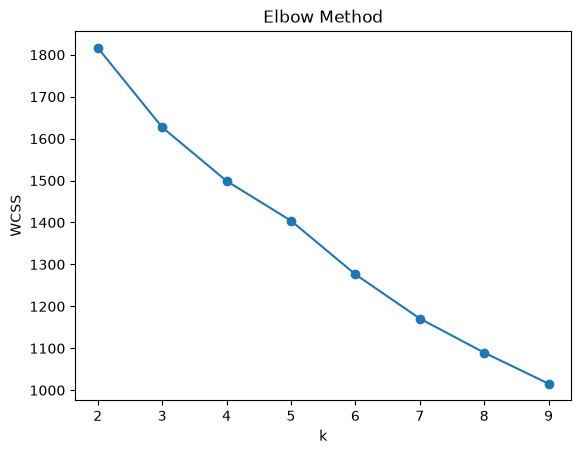

In [20]:
plt.plot(K, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("k"); plt.ylabel("WCSS")
plt.show()

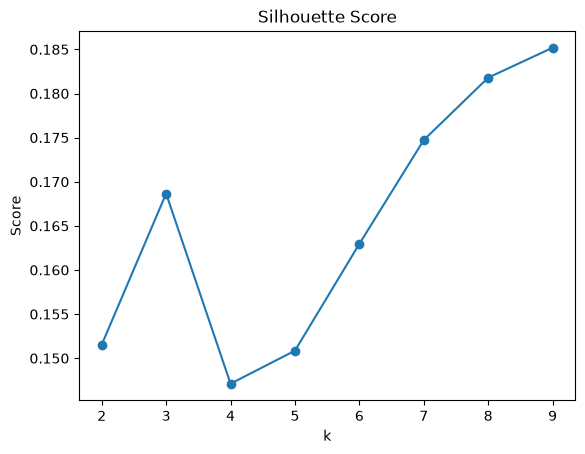

In [21]:
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k"); plt.ylabel("Score")
plt.show()

### Observation
- In the elbow chart, WCSS slows down after a certain k (the elbow point) — this is a potential optimal k.
- The silhouette score is highest where cluster separation is best.
- Both plots together help decide the final k value.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🎯 Fitting the Final KMeans Model
</h2>

<p style="font-size:16px; line-height:1.8;">
After reviewing the Elbow and Silhouette results, we choose the optimal k value, train the final KMeans model, and assign each restaurant to a cluster.
</p>

In [22]:
optimal_k = 4   
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

### Observation
- Each restaurant has now been assigned a Cluster label.
- These clusters group restaurants based on their cost, rating, sentiment, and cuisine profile.

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
🗺️ Visualizing Clusters in 2D with PCA
</h2>

<p style="font-size:16px; line-height:1.8;">
We reduce the high-dimensional feature space to 2 dimensions using PCA and plot the clusters, so it's clear how restaurants have been grouped into different segments.
</p>

In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_comp = pca.fit_transform(scaled_features)
df['PCA1'], df['PCA2'] = pca_comp[:,0], pca_comp[:,1]

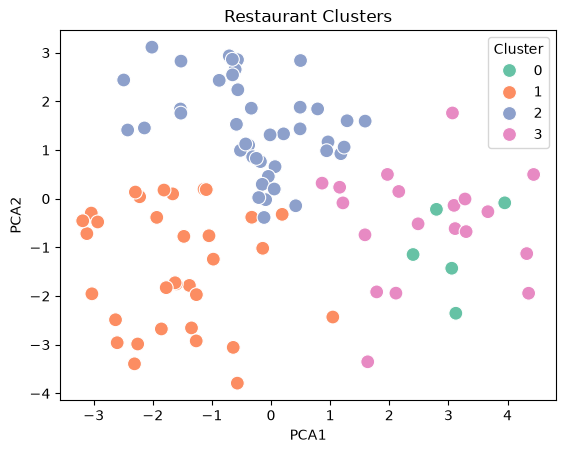

In [24]:
import seaborn as sns
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100)
plt.title("Restaurant Clusters")
plt.show()

### Observation
- The clusters appear visually grouped into distinct regions, indicating meaningful segmentation by the model.
- Some overlap is expected given the small dataset size (105 restaurants).

<h2 style="color:#E23744; border-left:6px solid #E23744; padding-left:10px;">
📊 Cluster Profiling — Business Meaning of Each Segment
</h2>

<p style="font-size:16px; line-height:1.8;">
We look at the average Cost, Rating, Sentiment, and Cuisine count per cluster to understand what type of restaurant each segment represents.
</p>

In [25]:
df.groupby('Cluster')[['Cost', 'Avg_Rating', 'Avg_Sentiment', 'Num_Cuisines', 'Total_Reviews']].mean()

,Cost,Avg_Rating,Avg_Sentiment,Num_Cuisines,Total_Reviews
Cluster,,,,,
0,1340.000000,4.552000,0.474060,3.800000,100.000000
1,527.272727,3.538642,0.226241,2.121212,99.212121
2,775.000000,3.392172,0.214122,3.261905,99.880952
3,1560.526316,3.940139,0.317370,3.789474,99.210526


### Observation
- Cluster [X] has high cost and high rating — likely a premium/fine-dining segment.
- Cluster [Y] has low cost but high review count — likely a budget, high-volume segment.
- Cluster [Z] has moderate cost but low sentiment — likely a segment needing improvement.
- (Replace these with your actual output numbers once you run the notebook)